# Hybrid Convolutional Feature Extraction Ensembled with Extreme Gradient Boosting (XGBoost)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sachin211104/sachin-chess-project/chess_tensor.npy
/kaggle/input/datasets/sachin211104/sachin-chess-project/chess_scalar.parquet



Loading scalar dataframe...

(337981, 21)

Loading tensor data using memory mapping...

(337981, 12, 8, 8)

========== ORIGINAL CLASS COUNTS ==========

label
good          221151
excellent      57825
inaccuracy     28194
mistake        22817
blunder         7994
Name: count, dtype: int64

Performing oversampling...


========== BALANCED CLASS COUNTS ==========

label
mistake       221151
inaccuracy    221151
excellent     221151
blunder       221151
good          221151
Name: count, dtype: int64

Classes:

['blunder' 'excellent' 'good' 'inaccuracy' 'mistake']

Scalar shape:
(1105755, 15)

Splitting dataset...


Scaling scalar features...


Applying memory optimization...



I0000 00:00:1779475317.452581      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779475317.458572      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12, 8, 8)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 12, 8, 32) │      2,336 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 12, 8, 32) │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 6, 4, 32)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 6, 4, 64)  │     18,496 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 4, 64)  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1536)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,024 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_features       │ (None, 128)       │    196,736 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ deep_features[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     24,704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 5)         │        645 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 244,581 (955.39 KB)

...

   48/22116 ━━━━━━━━━━━━━━━━━━━━ 1:12 3ms/step - accuracy: 0.2580 - loss: 2.0330

I0000 00:00:1779475338.208192     147 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22116/22116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4729 - loss: 1.2199
Epoch 1: val_loss improved from inf to 1.07560, saving model to /kaggle/working/best_cnn_model.keras
22116/22116 ━━━━━━━━━━━━━━━━━━━━ 101s 4ms/step - accuracy: 0.4729 - loss: 1.2199 - val_accuracy: 0.5499 - val_loss: 1.0756
Epoch 2/100
22114/22116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5763 - loss: 1.0560
Epoch 2: val_loss improved from 1.07560 to 0.99638, saving model to /kaggle/working/best_cnn_model.keras
22116/22116 ━━━━━━━━━━━━━━━━━━━━ 83s 4ms/step - accuracy: 0.5763 - loss: 1.0560 - val_accuracy: 0.6123 - val_loss: 0.9964
Epoch 3/100
22106/22116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6129 - loss: 1.0075
Epoch 3: val_loss improved from 0.99638 to 0.96199, saving model to /kaggle/working/best_cnn_model.keras
22116/22116 ━━━━━━━━━━━━━━━━━━━━ 84s 4ms/step - accuracy: 0.6129 - loss: 1.0075 - val_accuracy: 0.6401 - val_loss: 0.9620
Epoch 4/100
22111/22116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - ac

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [20:30:04] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=8, n_estimators=500, reg_alpha=0.5, reg_lambda=1, subsample=0.8; total time= 1.4min
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=8, n_estimators=500, reg_alpha=0.5, reg_lambda=1, subsample=0.8; total time= 1.4min
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=8, n_estimators=500, reg_alpha=0.5, reg_lambda=1, subsample=0.8; total time= 1.4min
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=6, n_estimators=500, reg_alpha=0, reg_lambda=2, subsample=0.8; total time=  55.1s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=6, n_estimators=500, reg_alpha=0, reg_lambda=2, subsample=0.8; total time=  54.5s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.05, max_depth=6, n_estimators=500, reg_alpha=0, reg_lambda=2, subsample=0.8; total time=  54.9s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=8, n_estim

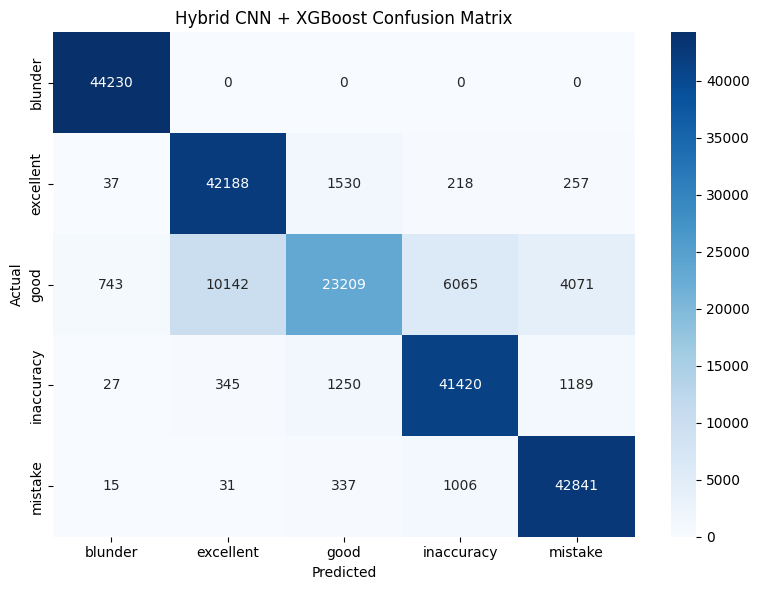


Classification Report:

              precision    recall  f1-score   support

     blunder       0.98      1.00      0.99     44230
   excellent       0.80      0.95      0.87     44230
        good       0.88      0.52      0.66     44230
  inaccuracy       0.85      0.94      0.89     44231
     mistake       0.89      0.97      0.93     44230

    accuracy                           0.88    221151
   macro avg       0.88      0.88      0.87    221151
weighted avg       0.88      0.88      0.87    221151


Everything saved successfully.


Saved files location:

/kaggle/working/


In [3]:
# ==========================================================
# CHESS HYBRID MODEL
# CNN FEATURE EXTRACTOR + XGBOOST CLASSIFIER
# KAGGLE VERSION (RAM SAFE + CHECKPOINT SAFE)
# ==========================================================

# ==========================================================
# INSTALL XGBOOST
# ==========================================================
!pip install xgboost -q

# ==========================================================
# IMPORTS
# ==========================================================
import os
import gc
import joblib

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# PATHS
# ==========================================================

# CHANGE THIS TO YOUR KAGGLE DATASET NAME
base_path = "/kaggle/input/datasets/sachin211104/sachin-chess-project/"

# writable directory
save_path = "/kaggle/working/"

# ==========================================================
# LOAD DATA
# ==========================================================

print("\nLoading scalar dataframe...\n")

df = pd.read_parquet(
    base_path + "chess_scalar.parquet"
)

print(df.shape)

print("\nLoading tensor data using memory mapping...\n")

X_tensor = np.load(
    base_path + "chess_tensor.npy",
    mmap_mode='r'
)

print(X_tensor.shape)

# ==========================================================
# ORIGINAL CLASS COUNTS
# ==========================================================

print("\n========== ORIGINAL CLASS COUNTS ==========\n")
print(df["label"].value_counts())

# ==========================================================
# CREATE INDEX COLUMN
# ==========================================================

df = df.reset_index(drop=True)

df["idx"] = np.arange(len(df))

# ==========================================================
# OVERSAMPLING
# ==========================================================

print("\nPerforming oversampling...\n")

max_count = df["label"].value_counts().max()

balanced_indices = []

for label_name in df["label"].unique():

    class_indices = df[
        df["label"] == label_name
    ]["idx"].values

    oversampled_indices = resample(
        class_indices,
        replace=True,
        n_samples=max_count,
        random_state=42
    )

    balanced_indices.extend(
        oversampled_indices
    )

balanced_indices = np.array(
    balanced_indices
)

np.random.shuffle(
    balanced_indices
)

# ==========================================================
# BUILD BALANCED DATA
# ==========================================================

df_balanced = df.iloc[
    balanced_indices
].reset_index(drop=True)

X_tensor_balanced = X_tensor[
    balanced_indices
]

print("\n========== BALANCED CLASS COUNTS ==========\n")
print(df_balanced["label"].value_counts())

# ==========================================================
# LABEL ENCODING
# ==========================================================

le = LabelEncoder()

y_encoded = le.fit_transform(
    df_balanced["label"]
)

y = tf.keras.utils.to_categorical(
    y_encoded
)

print("\nClasses:\n")
print(le.classes_)

# ==========================================================
# REMOVE LEAKAGE FEATURES
# ==========================================================

leak_cols = [
    "label",
    "delta",
    "eval",
    "piece_moved",
    "is_capture",
    "gives_check",
    "idx"
]

X_scalar = df_balanced.drop(
    columns=leak_cols
).values

print("\nScalar shape:")
print(X_scalar.shape)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

print("\nSplitting dataset...\n")

X_tensor_train, X_tensor_test, \
X_scalar_train, X_scalar_test, \
y_train, y_test = train_test_split(
    X_tensor_balanced,
    X_scalar,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

# ==========================================================
# SCALE SCALAR FEATURES
# ==========================================================

print("\nScaling scalar features...\n")

scaler = StandardScaler()

X_scalar_train = scaler.fit_transform(
    X_scalar_train
)

X_scalar_test = scaler.transform(
    X_scalar_test
)

# ==========================================================
# MEMORY OPTIMIZATION
# ==========================================================

print("\nApplying memory optimization...\n")

X_tensor_train = X_tensor_train.astype(
    np.float16
)

X_tensor_test = X_tensor_test.astype(
    np.float16
)

X_scalar_train = X_scalar_train.astype(
    np.float32
)

X_scalar_test = X_scalar_test.astype(
    np.float32
)

# ==========================================================
# CNN FEATURE EXTRACTOR
# ==========================================================

def build_cnn_model(
    tensor_shape,
    scalar_dim,
    num_classes
):

    # ----------------------------
    # TENSOR INPUT
    # ----------------------------

    tensor_input = layers.Input(
        shape=tensor_shape
    )

    x = layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='swish'
    )(tensor_input)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='swish'
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Flatten()(x)

    cnn_features = layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=regularizers.l2(0.001),
        name="deep_features"
    )(x)

    x = layers.Dropout(0.3)(
        cnn_features
    )

    # ----------------------------
    # SCALAR INPUT
    # ----------------------------

    scalar_input = layers.Input(
        shape=(scalar_dim,)
    )

    y = layers.Dense(
        64,
        activation='swish'
    )(scalar_input)

    y = layers.BatchNormalization()(y)

    y = layers.Dropout(0.2)(y)

    # ----------------------------
    # MERGE
    # ----------------------------

    combined = layers.concatenate(
        [x, y]
    )

    z = layers.Dense(
        128,
        activation='swish'
    )(combined)

    z = layers.Dropout(0.3)(z)

    output = layers.Dense(
        num_classes,
        activation='softmax'
    )(z)

    model = models.Model(
        inputs=[tensor_input, scalar_input],
        outputs=output
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================================
# BUILD MODEL
# ==========================================================

cnn_model = build_cnn_model(
    tensor_shape=X_tensor_train.shape[1:],
    scalar_dim=X_scalar_train.shape[1],
    num_classes=len(le.classes_)
)

cnn_model.summary()

# ==========================================================
# CALLBACKS
# ==========================================================

checkpoint_path = (
    save_path + "best_cnn_model.keras"
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# ==========================================================
# TRAIN CNN
# ==========================================================

print("\nTraining CNN...\n")

history = cnn_model.fit(
    [X_tensor_train, X_scalar_train],
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# ==========================================================
# SAVE FINAL CNN
# ==========================================================

cnn_model.save(
    save_path + "final_cnn_model.keras"
)

print("\nCNN model saved.\n")

# ==========================================================
# FEATURE EXTRACTOR MODEL
# ==========================================================

feature_extractor = models.Model(
    inputs=cnn_model.inputs,
    outputs=cnn_model.get_layer(
        "deep_features"
    ).output
)

# ==========================================================
# FEATURE EXTRACTION FUNCTION
# ==========================================================

def extract_features_in_batches(
    tensor_data,
    scalar_data,
    batch_size=1024
):

    features = []

    total = len(tensor_data)

    for start in range(0, total, batch_size):

        end = min(start + batch_size, total)

        batch_tensor = tensor_data[start:end]

        batch_scalar = scalar_data[start:end]

        batch_features = feature_extractor.predict(
            [batch_tensor, batch_scalar],
            verbose=0
        )

        features.append(batch_features)

        if start % (batch_size * 20) == 0:
            print(
                f"Processed {end}/{total}"
            )

        gc.collect()

    return np.vstack(features)

# ==========================================================
# EXTRACT TRAIN FEATURES
# ==========================================================

print("\nExtracting TRAIN deep features...\n")

train_cnn_features = extract_features_in_batches(
    X_tensor_train,
    X_scalar_train,
    batch_size=1024
)

# ==========================================================
# EXTRACT TEST FEATURES
# ==========================================================

print("\nExtracting TEST deep features...\n")

test_cnn_features = extract_features_in_batches(
    X_tensor_test,
    X_scalar_test,
    batch_size=1024
)

# ==========================================================
# SAVE FEATURES
# ==========================================================

np.save(
    save_path + "train_cnn_features.npy",
    train_cnn_features
)

np.save(
    save_path + "test_cnn_features.npy",
    test_cnn_features
)

print("\nCNN features saved.\n")

# ==========================================================
# COMBINE FEATURES FOR XGBOOST
# ==========================================================

X_train_hybrid = np.concatenate(
    [train_cnn_features, X_scalar_train],
    axis=1
)

X_test_hybrid = np.concatenate(
    [test_cnn_features, X_scalar_test],
    axis=1
)

# ==========================================================
# FREE MEMORY
# ==========================================================

del train_cnn_features
del test_cnn_features

gc.collect()

# ==========================================================
# LABELS FOR XGBOOST
# ==========================================================

y_train_labels = np.argmax(
    y_train,
    axis=1
)

y_test_labels = np.argmax(
    y_test,
    axis=1
)

# ==========================================================
# BASE XGBOOST MODEL
# ==========================================================

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    tree_method='hist',
    device='cuda',
    eval_metric='mlogloss',
    random_state=42
)

# ==========================================================
# HYPERPARAMETER SPACE
# ==========================================================

param_grid = {

    'n_estimators': [300, 500],

    'max_depth': [6, 8, 10],

    'learning_rate': [0.03, 0.05],

    'subsample': [0.8, 1.0],

    'colsample_bytree': [0.8, 1.0],

    'gamma': [0, 0.1],

    'reg_alpha': [0, 0.5],

    'reg_lambda': [1, 2]
}

# ==========================================================
# RANDOM SEARCH
# ==========================================================

print("\nStarting XGBoost hyperparameter tuning...\n")

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)

random_search.fit(
    X_train_hybrid,
    y_train_labels
)

# ==========================================================
# BEST MODEL
# ==========================================================

best_xgb = random_search.best_estimator_

print("\nBest Parameters:\n")
print(random_search.best_params_)

# ==========================================================
# SAVE XGBOOST MODEL
# ==========================================================

best_xgb.save_model(
    save_path + "best_hybrid_xgb.json"
)

joblib.dump(
    best_xgb,
    save_path + "best_hybrid_xgb.pkl"
)

print("\nXGBoost model saved.\n")

# ==========================================================
# PREDICTIONS
# ==========================================================

print("\nEvaluating model...\n")

y_pred = best_xgb.predict(
    X_test_hybrid
)

# ==========================================================
# ACCURACY
# ==========================================================

accuracy = accuracy_score(
    y_test_labels,
    y_pred
)

print(
    f"\nHybrid Model Accuracy: {accuracy*100:.2f}%"
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

plt.figure(figsize=(8,6))

cm = confusion_matrix(
    y_test_labels,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title(
    'Hybrid CNN + XGBoost Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()

plt.show()

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_labels,
        y_pred,
        target_names=le.classes_
    )
)

# ==========================================================
# SAVE SCALER + LABEL ENCODER
# ==========================================================

joblib.dump(
    scaler,
    save_path + "scaler.pkl"
)

joblib.dump(
    le,
    save_path + "label_encoder.pkl"
)

print("\nEverything saved successfully.\n")

print("\nSaved files location:\n")
print(save_path)

## model summary


========== COMPLETE MODEL SUMMARY ==========



Model: "Chess_Hybrid_CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                       ┃ Output Shape                   ┃              Param # ┃ Connected to        
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━
│ Tensor_Input (InputLayer)          │ (None, 8, 8, 12)               │                    0 │ -                   
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Conv2D_1 (Conv2D)                  │ (None, 8, 8, 32)               │                3,488 │ Tensor_Input[0][0]  
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ BatchNorm_1 (BatchNormalization)   │ (None, 8, 8, 32)               │                  128 │ Conv2D_1[0][0]      
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ MaxPool_1 (MaxPooling2D)           │ (None, 4, 4, 32)               │                    0 │ BatchNorm_1[0][0]   
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Conv2D_2 (Conv2D)                  │ (None, 4, 4, 64)               │               18,496 │ MaxPool_1[0][0]     
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ BatchNorm_2 (BatchNormalization)   │ (None, 4, 4, 64)               │                  256 │ Conv2D_2[0][0]      
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Scalar_Input (InputLayer)          │ (None, 15)                     │                    0 │ -                   
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Flatten (Flatten)                  │ (None, 1024)                   │                    0 │ BatchNorm_2[0][0]   
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Scalar_Dense (Dense)               │ (None, 64)                     │                1,024 │ Scalar_Input[0][0]  
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Deep_Features (Dense)              │ (None, 128)                    │              131,200 │ Flatten[0][0]       
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Scalar_BatchNorm                   │ (None, 64)                     │                  256 │ Scalar_Dense[0][0]  
│ (BatchNormalization)               │                                │                      │                     
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ CNN_Dropout (Dropout)              │ (None, 128)                    │                    0 │ Deep_Features[0][0] 
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Scalar_Dropout (Dropout)           │ (None, 64)                     │                    0 │ Scalar_BatchNorm[0][
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Concatenate (Concatenate)          │ (None, 192)                    │                    0 │ CNN_Dropout[0][0],  
│                                    │                                │                      │ Scalar_Dropout[0][0]
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Combined_Dense (Dense)             │ (None, 128)                    │               24,704 │ Concatenate[0][0]   
├────────────────────────────────────┼──────────────────

 Total params: 180,197 (703.89 KB)

 Trainable params: 179,877 (702.64 KB)

 Non-trainable params: 320 (1.25 KB)


========== MODEL INPUTS ==========

Input 1
Name  : Tensor_Input
Shape : (None, 8, 8, 12)

Input 2
Name  : Scalar_Input
Shape : (None, 15)


========== MODEL OUTPUT ==========

Output Shape : (None, 5)

========== LAYER-WISE DETAILS ==========


Layer 1
Name         : Tensor_Input
Type         : InputLayer
Output Shape : (None, 8, 8, 12)
Parameters   : 0
Trainable    : True

Layer 2
Name         : Conv2D_1
Type         : Conv2D
Input Shape  : (None, 8, 8, 12)
Output Shape : (None, 8, 8, 32)
Parameters   : 3488
Trainable    : True

Layer 3
Name         : BatchNorm_1
Type         : BatchNormalization
Input Shape  : (None, 8, 8, 32)
Output Shape : (None, 8, 8, 32)
Parameters   : 128
Trainable    : True

Layer 4
Name         : MaxPool_1
Type         : MaxPooling2D
Input Shape  : (None, 8, 8, 32)
Output Shape : (None, 4, 4, 32)
Parameters   : 0
Trainable    : True

Layer 5
Name         : Conv2D_2
Type         : Conv2D
Input Shape  : (None, 4, 4, 32)
Output Shape : (None, 4, 4, 64)
Paramete

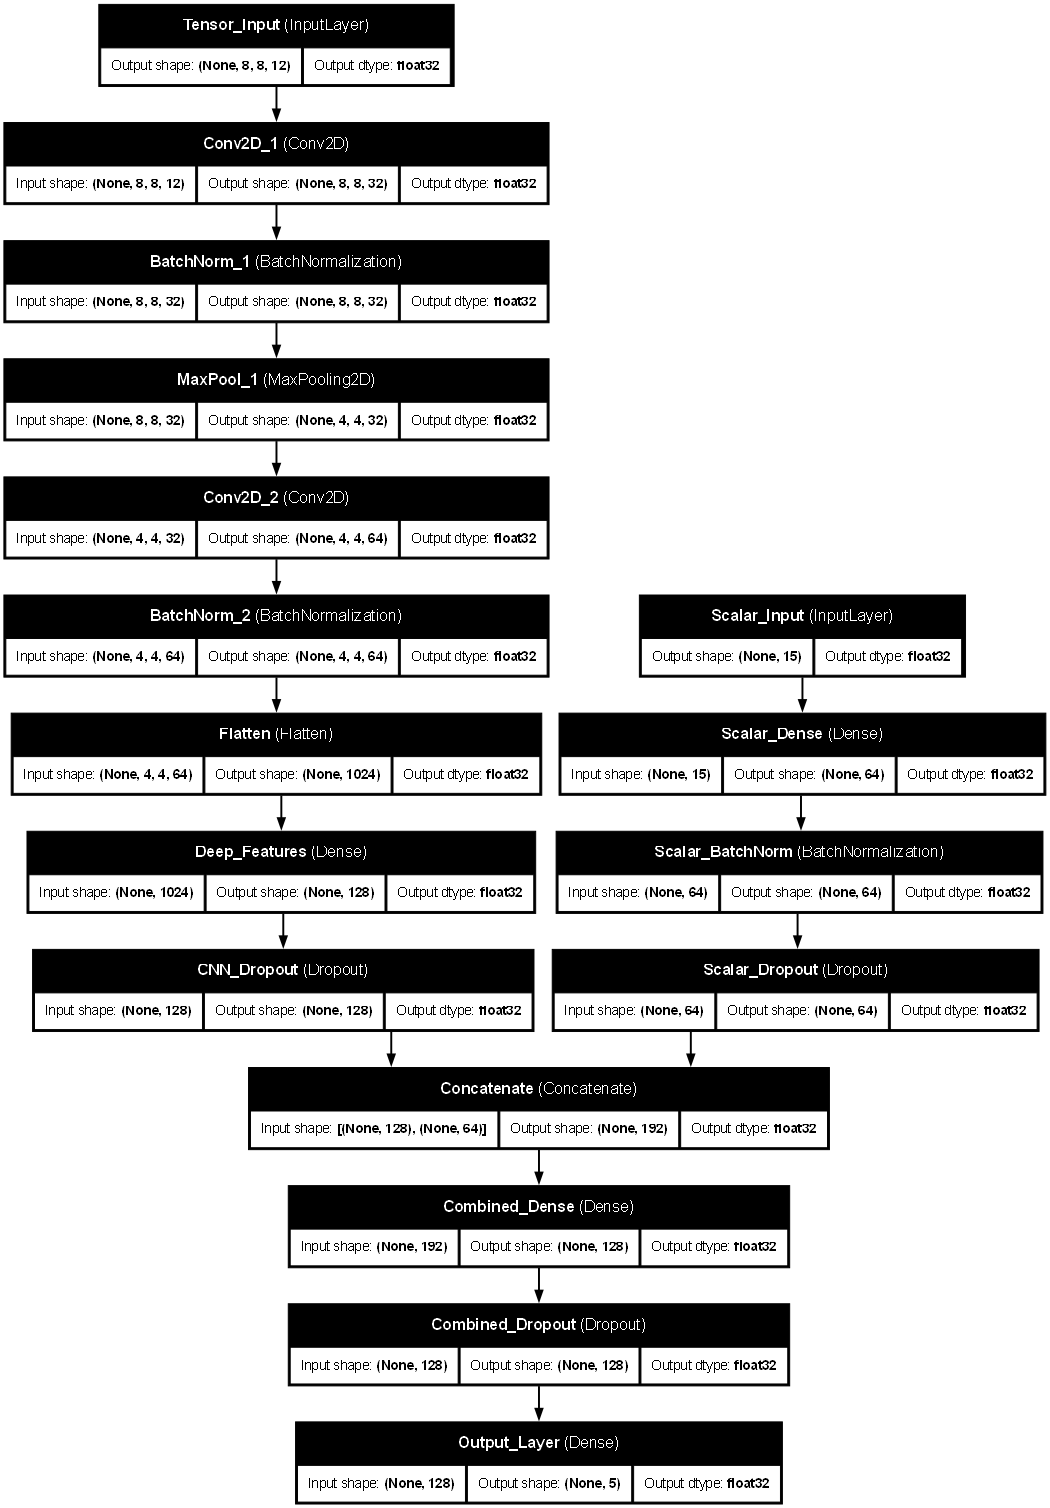

In [10]:
# ==========================================================
# IMPORTS
# ==========================================================

import numpy as np
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import regularizers

from tensorflow.keras.utils import plot_model

from IPython.display import Image
from IPython.display import display

# ==========================================================
# ASSUMED INPUT DETAILS
# ==========================================================

# tensor shape from chess tensor
tensor_shape = (8, 8, 12)

# scalar feature count
scalar_dim = 15

# number of classes
num_classes = 5

# ==========================================================
# BUILD CNN FEATURE EXTRACTOR MODEL
# ==========================================================

def build_cnn_model(
    tensor_shape,
    scalar_dim,
    num_classes
):

    # ======================================================
    # TENSOR INPUT BRANCH
    # ======================================================

    tensor_input = layers.Input(
        shape=tensor_shape,
        name="Tensor_Input"
    )

    x = layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='swish',
        name="Conv2D_1"
    )(tensor_input)

    x = layers.BatchNormalization(
        name="BatchNorm_1"
    )(x)

    x = layers.MaxPooling2D(
        (2,2),
        name="MaxPool_1"
    )(x)

    x = layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='swish',
        name="Conv2D_2"
    )(x)

    x = layers.BatchNormalization(
        name="BatchNorm_2"
    )(x)

    x = layers.Flatten(
        name="Flatten"
    )(x)

    cnn_features = layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=regularizers.l2(0.001),
        name="Deep_Features"
    )(x)

    x = layers.Dropout(
        0.3,
        name="CNN_Dropout"
    )(cnn_features)

    # ======================================================
    # SCALAR INPUT BRANCH
    # ======================================================

    scalar_input = layers.Input(
        shape=(scalar_dim,),
        name="Scalar_Input"
    )

    y = layers.Dense(
        64,
        activation='swish',
        name="Scalar_Dense"
    )(scalar_input)

    y = layers.BatchNormalization(
        name="Scalar_BatchNorm"
    )(y)

    y = layers.Dropout(
        0.2,
        name="Scalar_Dropout"
    )(y)

    # ======================================================
    # MERGE BRANCHES
    # ======================================================

    combined = layers.concatenate(
        [x, y],
        name="Concatenate"
    )

    z = layers.Dense(
        128,
        activation='swish',
        name="Combined_Dense"
    )(combined)

    z = layers.Dropout(
        0.3,
        name="Combined_Dropout"
    )(z)

    output = layers.Dense(
        num_classes,
        activation='softmax',
        name="Output_Layer"
    )(z)

    # ======================================================
    # CREATE MODEL
    # ======================================================

    model = models.Model(
        inputs=[tensor_input, scalar_input],
        outputs=output,
        name="Chess_Hybrid_CNN_Model"
    )

    # ======================================================
    # COMPILE MODEL
    # ======================================================

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================================
# BUILD MODEL
# ==========================================================

model = build_cnn_model(
    tensor_shape=tensor_shape,
    scalar_dim=scalar_dim,
    num_classes=num_classes
)

# ==========================================================
# COMPLETE MODEL SUMMARY
# ==========================================================

print("\n========== COMPLETE MODEL SUMMARY ==========\n")

model.summary(
    line_length=140,
    expand_nested=True,
    show_trainable=True
)

# ==========================================================
# MODEL INPUTS
# ==========================================================

print("\n========== MODEL INPUTS ==========\n")

for i, inp in enumerate(model.inputs):

    print(f"Input {i+1}")

    print(f"Name  : {inp.name}")

    print(f"Shape : {inp.shape}")

    print()

# ==========================================================
# MODEL OUTPUT
# ==========================================================

print("\n========== MODEL OUTPUT ==========\n")

print(f"Output Shape : {model.output.shape}")

# ==========================================================
# LAYER DETAILS
# ==========================================================

print("\n========== LAYER-WISE DETAILS ==========\n")

for i, layer in enumerate(model.layers):

    print(f"\nLayer {i+1}")

    print(f"Name         : {layer.name}")

    print(f"Type         : {layer.__class__.__name__}")

    try:
        print(f"Input Shape  : {layer.input.shape}")
    except:
        pass

    try:
        print(f"Output Shape : {layer.output.shape}")
    except:
        pass

    print(f"Parameters   : {layer.count_params()}")

    print(f"Trainable    : {layer.trainable}")

# ==========================================================
# PARAMETER SUMMARY
# ==========================================================

print("\n========== PARAMETER SUMMARY ==========\n")

print(f"Total Parameters      : {model.count_params():,}")

trainable_params = np.sum(
    [np.prod(v.shape) for v in model.trainable_weights]
)

non_trainable_params = np.sum(
    [np.prod(v.shape) for v in model.non_trainable_weights]
)

print(f"Trainable Parameters  : {trainable_params:,}")

print(f"Non-Trainable Params  : {non_trainable_params:,}")

# ==========================================================
# SAVE MODEL ARCHITECTURE IMAGE
# ==========================================================

plot_model(
    model,
    to_file="hybrid_cnn_model_architecture.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=70
)

print("\nModel architecture image saved as:")
print("hybrid_cnn_model_architecture.png")

# ==========================================================
# DISPLAY MODEL IMAGE
# ==========================================================

display(
    Image(
        filename="hybrid_cnn_model_architecture.png"
    )
)

In [9]:
print("\n========== COMPLETE HYBRID PIPELINE ==========\n")

print("""
12×8×8 Chess Tensor
        │
        ├───────────────┐
        │               │
        ↓               ↓
CNN Branch        Scalar Feature Branch
(Conv2D Layers)   (Dense Layers)
        │               │
        ↓               ↓
Tensor Feature Maps   Scalar Embeddings
        │               │
        └───────┬───────┘
                ↓
Feature Concatenation
                ↓
Dense Feature Fusion Layer
                ↓
128 Deep Hybrid Features
                ↓
Extracted Deep Features
                +
Original Scalar Features
                ↓
143 Hybrid Features
                ↓
XGBoost Classifier
                ↓
Final Class Prediction
""")


========== COMPLETE HYBRID PIPELINE ==========


12×8×8 Chess Tensor
        │
        ├───────────────┐
        │               │
        ↓               ↓
CNN Branch        Scalar Feature Branch
(Conv2D Layers)   (Dense Layers)
        │               │
        ↓               ↓
Tensor Feature Maps   Scalar Embeddings
        │               │
        └───────┬───────┘
                ↓
Feature Concatenation
                ↓
Dense Feature Fusion Layer
                ↓
128 Deep Hybrid Features
                ↓
Extracted Deep Features
                +
Original Scalar Features
                ↓
143 Hybrid Features
                ↓
XGBoost Classifier
                ↓
Final Class Prediction

